In [ ]:
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import tensorflow as tf
import skimage
print('numpy', np.__version__)
print('matplotlib', plt.matplotlib.__version__)
print('tensorflow', tf.__version__)
print('skimage', skimage.__version__)

numpy 2.4.4
matplotlib 3.10.8
tensorflow 2.21.0
skimage 0.26.0


In [ ]:
def unpickle(file_path):
    with open(file_path, "rb") as f:
        return pickle.load(f, encoding="latin1")


def load_cifar10(cifar_dir):
    meta = unpickle(os.path.join(cifar_dir, "batches.meta"))
    label_names = meta["label_names"]

    x_train_list, y_train_list = [], []
    for i in range(1, 6):
        batch = unpickle(os.path.join(cifar_dir, f"data_batch_{i}"))
        x_train_list.append(batch["data"])
        y_train_list.append(np.array(batch["labels"]))

    X_train = np.concatenate(x_train_list, axis=0)
    y_train = np.concatenate(y_train_list, axis=0)

    test_batch = unpickle(os.path.join(cifar_dir, "test_batch"))
    X_test = test_batch["data"]
    y_test = np.array(test_batch["labels"])

    X_train = X_train.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    X_test = X_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

    return X_train, y_train, X_test, y_test, label_names


cifar_dir = "cifar-10-batches-py"
if not os.path.exists(cifar_dir):
    cifar_dir = os.path.join(".", "cifar-10-batches-py")

X_train, y_train, X_test, y_test, label_names = load_cifar10(cifar_dir)

X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

c:\Users\tevyn\OneDrive - The University of Queensland\Documents\CV_DL\Assignment 2\.venv311\Scripts\python.exe
TensorFlow: 2.21.0


C:\Users\tevyn\AppData\Local\Temp\ipykernel_29484\418232906.py:19: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(f, encoding="latin1")


X_train: (50000, 32, 32, 3)
y_train: (50000,)
X_test: (10000, 32, 32, 3)
y_test: (10000,)
Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.4224 - loss: 1.6317 - val_accuracy: 0.1836 - val_loss: 6.9760 - learning_rate: 0.0010
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.5510 - loss: 1.2514 - val_accuracy: 0.5382 - val_loss: 1.3540 - learning_rate: 0.0010
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.6133 - loss: 1.0861 - val_accuracy: 0.6318 - val_loss: 1.0829 - learning_rate: 0.0010
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.6558 - loss: 0.9723 - val_accuracy: 0.5862 - val_loss: 1.2204 - learning_rate: 0.0010
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.6878 - loss: 0.8816 - val_accuracy: 0.5006 - val_loss: 1.6350 - learning_rate: 0.0010
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.7136 - loss: 0.8004 - val_accuracy: 0.5034 - val_loss: 1.6357 - learning_rate

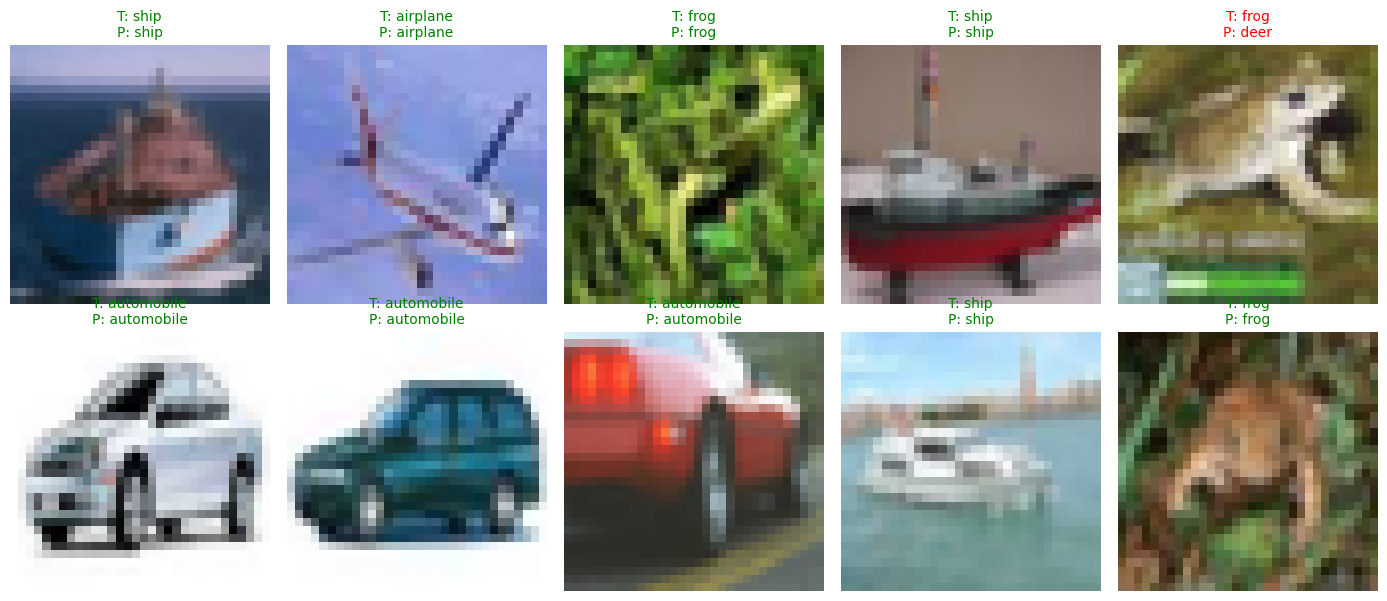

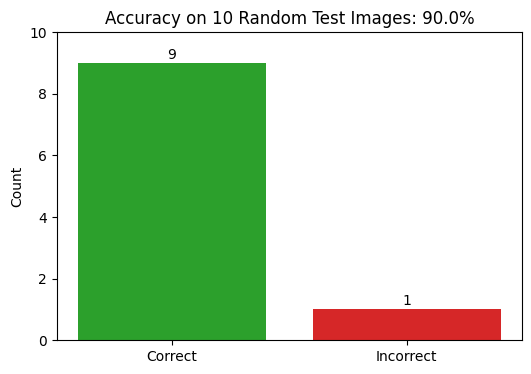

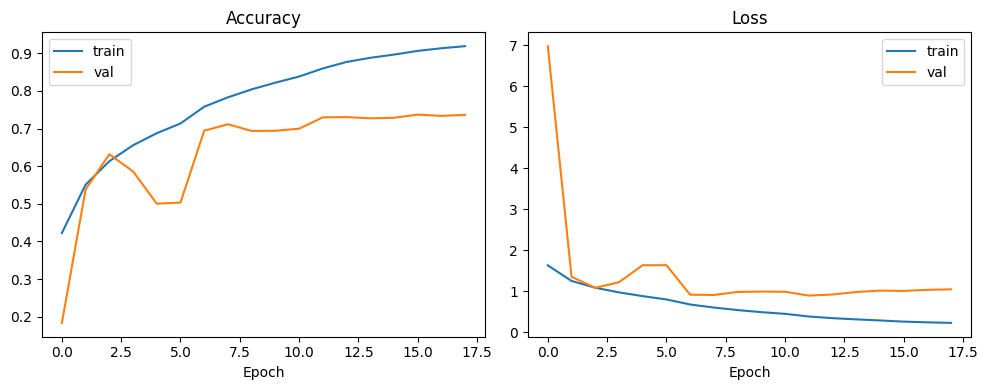

In [ ]:
# Train a simple CNN on CIFAR-10 training data, then evaluate 10 random test images

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(sys.executable)
print("TensorFlow:", tf.__version__)

# Build a simple but stable CNN
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(10, activation="softmax"),
])

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
]

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1,
)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nFull test accuracy: {test_acc * 100:.2f}%")

rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_test), size=10, replace=False)
X_sample = X_test[sample_idx]
y_true = y_test[sample_idx]

probs = model.predict(X_sample, verbose=0)
y_pred = np.argmax(probs, axis=1)

correct = (y_pred == y_true)
sample_accuracy = float(np.mean(correct))

print("\nPredictions on 10 random test images:")
for i in range(10):
    print(
        f"Image {i+1:02d} | true: {label_names[y_true[i]]:>10s} | "
        f"pred: {label_names[y_pred[i]]:>10s} | correct: {bool(correct[i])}"
    )

print(f"\nAccuracy on these 10 random test images: {sample_accuracy * 100:.2f}%")

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, img, t, p, c in zip(axes.flat, X_sample, y_true, y_pred, correct):
    ax.imshow(img)
    ax.set_title(f"T: {label_names[t]}\nP: {label_names[p]}", color=("green" if c else "red"), fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
bars = plt.bar(["Correct", "Incorrect"], [int(correct.sum()), int((~correct).sum())], color=["#2ca02c", "#d62728"])
plt.title(f"Accuracy on 10 Random Test Images: {sample_accuracy * 100:.1f}%")
plt.ylabel("Count")
for b in bars:
    h = b.get_height()
    plt.text(b.get_x() + b.get_width() / 2, h + 0.05, str(int(h)), ha="center", va="bottom")
plt.ylim(0, 10)
plt.show()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.tight_layout()
plt.show()